# A linearized forward model for excitation-induced phase reconstruction

This notebook develops the *linearized forward model* for light-activated functional
electron ptychography (see "Future work" in the research proposal). Instead of jointly
reconstructing the light-off and light-on states (slow, non-convex — the approach in
notebooks 02/03), it assumes the light-off object phase $\varphi_{off}$ is already
known and treats the excitation phase $\Delta\varphi = \varphi_{on}-\varphi_{off}$ as a
*small* perturbation:

$$\psi_{on}(\mathbf{r}) = \psi_{off}(\mathbf{r})\,e^{i\Delta\varphi(\mathbf{r})}
\approx \psi_{off}(\mathbf{r})\,(1+i\Delta\varphi(\mathbf{r}))$$

Expanding the diffracted intensity to first order in $\Delta\varphi$ gives an expression
that is **linear** in $\Delta\varphi$:

$$I_{on}(\Delta\varphi) \approx I_{off} - 2\,\mathrm{Im}\!\left[\Psi_{off}^{*}\cdot
\mathcal{F}\!\left(\psi_{off}\,\Delta\varphi\right)\right]$$

$$\Delta\varphi^{*} = \operatorname*{argmin}_{\Delta\varphi}\ \sum_{k}
\left(I_{on}(\Delta\varphi) - I_{on,\mathrm{meas}}\right)^2$$

where $\Psi_{off}=\mathcal{F}(\psi_{off})$ is the light-off exit wave in reciprocal
space. Because $I_{on}$ is linear in $\Delta\varphi$, this least-squares problem is a
**convex quadratic** with a single minimum — every fit below solves it with full-batch
`torch.optim.LBFGS` (quasi-Newton + a strong-Wolfe line search), which suits a convex
problem far better than mini-batch first-order descent: no stochastic-gradient noise
and no learning-rate tuning, and it converges in a handful of outer iterations.

## Why this notebook has three steps

The end goal is to run this on **real experimental data**, where the only thing an
interlaced acquisition ever records is a single *merged* (checkerboard-interlaced)
scan: light-off and light-on frames at disjoint, alternating positions, never both at
the same position. That scan is also inescapably **dose-limited** (finite electron
dose $\to$ Poisson shot noise on every diffraction pattern). So the real pipeline has
to (a) reconstruct $\varphi_{off}$ from *only* the light-off frames actually present in
the merged scan, (b) use that reconstruction's own object and probe to
forward-simulate what the light-off diffraction pattern would have been at every
light-on position — i.e. *fill in* the missing light-off frames — and (c) fit
$\Delta\varphi$ against the real, measured light-on frames using the linear model
above. This notebook builds that pipeline in three steps of increasing realism:

1. **Ground-truth $\varphi_{off}$.** $\psi_{off}$ is simulated directly from the known
   (simulated) light-off phase and an ideal probe. This is a cheat no real experiment
   can perform, but it establishes the ceiling for how well the linear fit can do when
   $\varphi_{off}$ is exactly known.
2. **Reconstructed $\varphi_{off}$.** $\varphi_{off}$ and the probe instead come from a
   genuine iterative ptychographic reconstruction that uses *only* the light-off pixels
   of the merged scan — exactly what a real experiment can provide. That
   reconstruction's own forward model fills in the missing light-off frames at the
   light-on positions, and $\Delta\varphi$ is fit against the real light-on data.
3. **Dose sweep.** Step 2's full pipeline (a fresh reconstruction *and* linear fit every
   time, no privileged information) is repeated across a range of electron doses, to
   see how reconstruction quality degrades as shot noise grows — the regime that
   determines whether this method is usable on real data at all.

All three steps use the same simulated bilayer-defect phase maps as
`04 - direct methods - multiplex SSB.ipynb`.

In [1]:
import pickle
import gc
import os

import numpy as np
import torch
from matplotlib import pyplot as plt

from abtem.waves import Probe
from abtem.core.energy import energy2sigma
from abtem.potentials.iam import PotentialArray
from abtem import PixelatedDetector
from abtem.scan import GridScan

import method_wrappers

ACC_VOLTAGE     = 60e3  # eV
PROBE_SEMIANGLE = 30    # mrad
PROBE_DEFOCUS   = 0     # Angstrom
SCAN_STEP_SIZE  = 0.2   # Angstrom, same as notebook 04

sigma = float(energy2sigma(ACC_VOLTAGE))
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

cuda:0


'cuda'

(np.float64(-0.5), np.float64(200.5), np.float64(200.5), np.float64(-0.5))

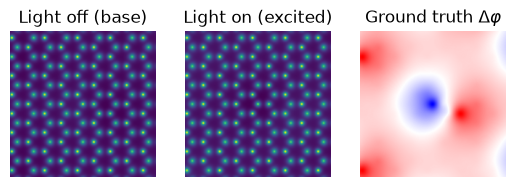

In [2]:
with open('bcenters_base_excited_phases_wide_fov.pkl', 'rb') as f:
    data = pickle.load(f)

base_phase = data['base'][25:-25, 25:-25]
excited_phase = data['excited'][25:-25, 25:-25]
x = data['x'][25:-25]
y = data['y'][25:-25]

dx = x[1] - x[0]
dy = y[1] - y[0]
gt_delta_phi = (excited_phase - base_phase).astype(np.float32)

plt.subplot(1, 3, 1)
plt.title('Light off (base)')
plt.imshow(base_phase)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Light on (excited)')
plt.imshow(excited_phase)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title(r'Ground truth $\Delta\varphi$')
plt.imshow(gt_delta_phi, cmap='bwr')
plt.axis('off')

## Simulate the interlaced 4D-STEM acquisition

A single-slice (thin-object) potential is built from each phase map and scanned with a
30 mrad, 60 keV probe at 0.2 Å steps. We simulate the *full* light-off and light-on
4D-STEM datasets, then build the interlaced (checkerboard) acquisition. In a real
experiment only the checkerboard-interlaced `merged_scan` would exist; here we also
keep the full `I_off_full`/`I_on_full` datasets around purely so results can be checked
against ground truth.

In [3]:
def make_potential(phase_image):
    V = (phase_image / sigma)[np.newaxis, :, :].astype(np.float32)
    return PotentialArray(array=V, slice_thickness=1, sampling=(dx, dy))


potential_off = make_potential(base_phase)
potential_on = make_potential(excited_phase)

probe = Probe(energy=ACC_VOLTAGE, semiangle_cutoff=PROBE_SEMIANGLE, defocus=PROBE_DEFOCUS)
probe.match_grid(potential_off)

scan = GridScan(
    start=(0.0, 0.0),
    end=potential_off.extent,
    potential=potential_off,
    sampling=SCAN_STEP_SIZE,
    endpoint=True,
)
positions = scan.get_positions()  # (nx_scan, ny_scan, 2), Angstrom
detector = PixelatedDetector(max_angle='valid')

# Cached to disk: abtem's multislice simulation turned out not to be bit-exact
# run-to-run (GPU FFT reduction order isn't deterministic, even at fixed physics),
# and everything downstream -- the dose sweep in particular -- is sensitive enough
# to that ~1e-7-level jitter that it occasionally changes which side of a marginal
# dose's noise floor the reconstruction lands on. Caching the one array that's
# actually non-deterministic makes the rest of the notebook reproducible run-to-run.
_sim_cache_path = 'sim_cache_wide_fov.pkl'
if os.path.exists(_sim_cache_path):
    with open(_sim_cache_path, 'rb') as f:
        I_off_full, I_on_full = pickle.load(f)
else:
    base_meas = probe.scan(potential_off, scan=scan, detectors=detector)
    base_meas.compute()

    excited_meas = probe.scan(potential_on, scan=scan, detectors=detector)
    excited_meas.compute()

    I_off_full = np.asarray(base_meas.array)
    I_on_full = np.asarray(excited_meas.array)
    with open(_sim_cache_path, 'wb') as f:
        pickle.dump((I_off_full, I_on_full), f)

I_off_full.shape

(98, 98, 95, 95)

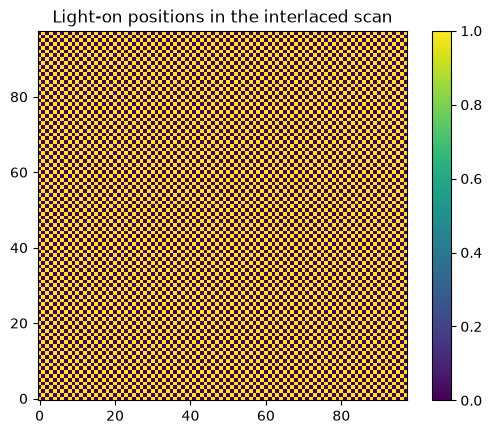

In [4]:
# checkerboard interlacing, same convention as notebook 04
nx_scan, ny_scan = I_off_full.shape[:2]
ii, jj = np.meshgrid(np.arange(nx_scan), np.arange(ny_scan), indexing='ij')
on_mask = ((ii + jj) % 2 == 0)

merged_scan = I_off_full.copy()
merged_scan[on_mask] = I_on_full[on_mask]

plt.imshow(on_mask.T, origin='lower')
plt.title('Light-on positions in the interlaced scan')
plt.colorbar()

## Step 1 — linearized reconstruction using the known (simulated) $\varphi_{off}$

Here $\psi_{off}(\mathbf{r};\mathbf{R}) = P(\mathbf{r}-\mathbf{R})\,e^{i\varphi_{off}
(\mathbf{r})}$ is built directly from the known `base_phase` and an ideal `abtem`
probe, at every light-on scan position — this *is* "filling in the missing light-off
frames", just done with a cheat available only in simulation. The result is the
best-case ceiling for the fit in Step 2, where $\varphi_{off}$ instead comes from a
real reconstruction.

### Fast forward model for $\psi_{off}$

Rather than re-running the full multislice simulation (which only returns
intensities), we shift the free-space probe to each scan position with `probe.build`,
multiply by the known light-off transmission function, and FFT-crop to the same
"valid" detector window used above. Because the potential here is a single thin slice,
this is mathematically identical to the `probe.scan` forward model used above (no
multiple scattering to account for) — checked below against the true simulated
intensities before it's trusted.

In [5]:
T_off = torch.from_numpy(np.exp(1j * base_phase).astype(np.complex64)).to(device)
ny, nx = base_phase.shape
ndet = I_off_full.shape[-1]
cy, cx = ny // 2, nx // 2
half = ndet // 2


def psi_off_and_Psi_off(scan_positions, chunk=2000):
    psi_list, Psi_list = [], []
    for start in range(0, len(scan_positions), chunk):
        batch = scan_positions[start:start + chunk]
        w = probe.build(scan=batch)
        w.compute()
        free_probe = torch.from_numpy(np.asarray(w.array).astype(np.complex64)).to(device)
        psi = free_probe * T_off[None]
        Psi_full = torch.fft.fftshift(torch.fft.fft2(psi), dim=(-2, -1))
        Psi = Psi_full[..., cy - half:cy + half + 1, cx - half:cx + half + 1]
        psi_list.append(psi)
        Psi_list.append(Psi)
    return torch.cat(psi_list, dim=0), torch.cat(Psi_list, dim=0)


# sanity check: does the fast thin-object model reproduce the actual multislice result?
check_positions = positions[::40, ::40].reshape(-1, 2)
psi_check, Psi_check = psi_off_and_Psi_off(check_positions)
I_check_fast = (Psi_check.abs() ** 2).cpu().numpy()

check_ix, check_iy = np.meshgrid(np.arange(0, nx_scan, 40), np.arange(0, ny_scan, 40), indexing='ij')
I_check_true = I_off_full[check_ix.ravel(), check_iy.ravel()]

rel_err = np.abs(I_check_fast - I_check_true).max() / I_check_true.max()
corr = np.corrcoef(I_check_fast.ravel(), I_check_true.ravel())[0, 1]
print(f'fast forward-model vs. true multislice intensities: max rel. err={rel_err:.2e}, corr={corr:.10f}')

fast forward-model vs. true multislice intensities: max rel. err=1.32e-06, corr=1.0000000000


### Build $\psi_{off}$ / $\Psi_{off}$ at every light-on scan position

These depend only on the (known) light-off state; they are computed once and reused
throughout the fit below.

In [6]:
on_idx = np.argwhere(on_mask)
on_positions = positions[on_idx[:, 0], on_idx[:, 1]]
n_on = len(on_idx)
print(f'{n_on} light-on scan positions out of {nx_scan * ny_scan}')

psi_off_real, Psi_off_k = psi_off_and_Psi_off(on_positions)

I_off_on_pos = torch.from_numpy(I_off_full[on_idx[:, 0], on_idx[:, 1]].astype(np.float32)).to(device)
I_on_meas = torch.from_numpy(I_on_full[on_idx[:, 0], on_idx[:, 1]].astype(np.float32)).to(device)

# normalize intensities to O(1) so the optimizer's step size behaves well
norm_const = I_off_on_pos.mean()
I_off_n = I_off_on_pos / norm_const
I_on_n = I_on_meas / norm_const
Psi_off_k_n = Psi_off_k / torch.sqrt(norm_const)

4802 light-on scan positions out of 9604


tasks:  23%|##3       | 3/13 [00:00<00:02,  3.52it/s]

tasks:  23%|##3       | 3/13 [00:00<00:02,  3.50it/s]

tasks:  43%|####2     | 3/7 [00:00<00:01,  3.84it/s]

### Linearized fit

$$\Delta I(\Delta\varphi) = -2\,\mathrm{Im}\!\left[\Psi_{off}^{*}\cdot
\mathcal{F}\!\left(\psi_{off}\,\Delta\varphi\right)\right]$$

(the sign follows directly from expanding $|\Psi_{off}+i\,\mathcal{F}(\psi_{off}
\Delta\varphi)|^2$ to first order). $\Delta\varphi$ is optimized as a zero-mean field
(the overall phase offset is not observable from intensities alone) over all light-on
positions in a single full-batch LBFGS step.

The residuals are also weighted by $1/I_{off}$: the measured intensities are Poisson
counts, so their variance scales with their own mean count rate, and an *unweighted*
least-squares fit implicitly (and wrongly) treats a noisy, near-empty detector pixel as
just as informative as a bright, well-measured one. Weighting each squared residual by
$1/I_{off}$ (a stable, noise-free proxy for the local count level, since $\Delta\varphi$
is a small perturbation on top of it) approximates the correctly-weighted (Gauss-Newton)
expansion of the Poisson negative log-likelihood — standard practice for Poisson-limited
data. The weights are fixed constants, independent of $\Delta\varphi$, so this is still
a convex quadratic form, just a better-conditioned one that makes proper use of every
pixel's actual statistical reliability.

The closure also records its loss at every LBFGS evaluation, purely to plot afterward —
a smooth, monotonically decreasing curve with no oscillation or plateaus-then-drops is
exactly what a convex problem being solved correctly should look like, and is worth
actually checking rather than assuming.

final loss = 1.020e-06   (35 closure evaluations)


Text(0.5, 1.0, 'Step 1 loss trace — smooth, monotonic descent to one minimum (as expected for a convex problem)')

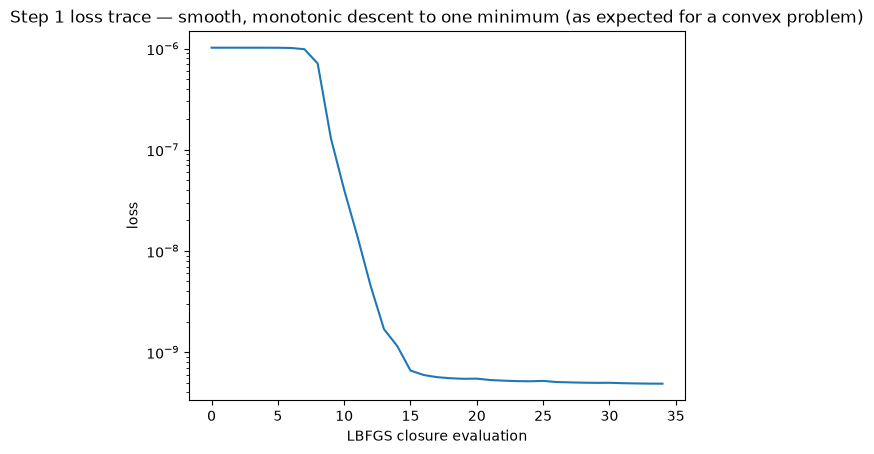

In [7]:
def forward_delta_I(dphi, idx):
    pert = psi_off_real[idx] * dphi[None]
    Pert_full = torch.fft.fftshift(torch.fft.fft2(pert), dim=(-2, -1))
    Pert_k = Pert_full[..., cy - half:cy + half + 1, cx - half:cx + half + 1] / torch.sqrt(norm_const)
    return -2.0 * torch.imag(torch.conj(Psi_off_k_n[idx]) * Pert_k)


# Poisson-appropriate weighting: I_off_n is a stable proxy for each pixel's own count
# level, so 1/I_off_n approximates inverse-variance weighting (capped so the very
# faint dark-field tail of the detector, which is almost all noise, can't dominate).
poisson_weight = 1.0 / (I_off_n + 0.2 * I_off_n.mean())
poisson_weight = torch.clamp(poisson_weight, max=10.0 / I_off_n.mean())
poisson_weight = poisson_weight / poisson_weight.mean()

delta_phi_raw = torch.zeros((ny, nx), dtype=torch.float32, device=device, requires_grad=True)
optimizer = torch.optim.LBFGS(
    [delta_phi_raw],
    lr=1.0,
    max_iter=100,
    tolerance_grad=1e-10,
    tolerance_change=1e-12,
    line_search_fn="strong_wolfe",
)

idx_all = torch.arange(n_on, device=device)
loss_history = []


def closure():
    optimizer.zero_grad()
    delta_phi = delta_phi_raw - delta_phi_raw.mean()
    I_on_pred = I_off_n[idx_all] + forward_delta_I(delta_phi, idx_all)
    loss = torch.mean(poisson_weight[idx_all] * (I_on_pred - I_on_n[idx_all]) ** 2)
    loss.backward()
    loss_history.append(loss.item())
    return loss


loss_final = optimizer.step(closure)
delta_phi = (delta_phi_raw - delta_phi_raw.mean()).detach()
print(f'final loss = {loss_final.item():.3e}   ({len(loss_history)} closure evaluations)')

plt.plot(loss_history)
plt.yscale('log')
plt.xlabel('LBFGS closure evaluation')
plt.ylabel('loss')
plt.title('Step 1 loss trace — smooth, monotonic descent to one minimum (as expected for a convex problem)')

### Result: reconstructed vs. ground-truth excitation phase

Step 1 (ground-truth phi_off):  NRMSE = 0.246   correlation = 0.997


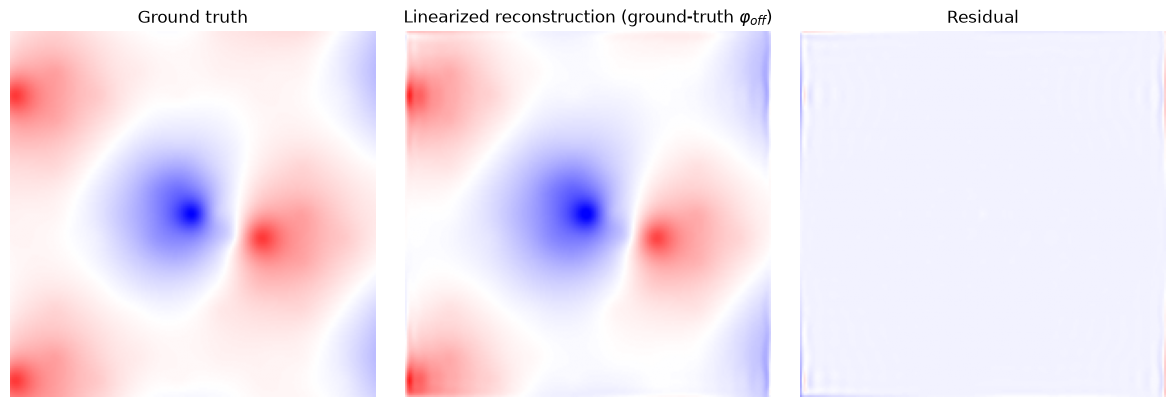

In [8]:
recon = delta_phi.detach().cpu().numpy()

nrmse = np.sqrt(np.sum((recon - gt_delta_phi) ** 2) / np.sum(gt_delta_phi ** 2))
corr = np.corrcoef(recon.ravel(), gt_delta_phi.ravel())[0, 1]
print(f'Step 1 (ground-truth phi_off):  NRMSE = {nrmse:.3f}   correlation = {corr:.3f}')

vmax = np.abs(gt_delta_phi).max()
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(gt_delta_phi, cmap='bwr', vmin=-vmax, vmax=vmax)
axs[0].set_title('Ground truth')
axs[1].imshow(recon, cmap='bwr', vmin=-vmax, vmax=vmax)
axs[1].set_title('Linearized reconstruction (ground-truth $\\varphi_{off}$)')
axs[2].imshow(recon - gt_delta_phi, cmap='bwr', vmin=-vmax, vmax=vmax)
axs[2].set_title('Residual')
for ax in axs:
    ax.axis('off')
plt.tight_layout()

## Step 2 — reconstructing $\varphi_{off}$ from the merged scan itself

A real experiment never has access to `base_phase` or the full `I_off_full`: the only
recorded data is `merged_scan`, which holds a light-off frame *or* a light-on frame at
each position, never both. This step removes both cheats from Step 1:

* $\varphi_{off}$ and the probe come from a genuine iterative ptychographic
  reconstruction, driven **only** by the real, individually measured light-off frames
  of `merged_scan`, each at its own true (native) scan position — diffraction patterns
  are never averaged together. (Averaging two frames from physically distinct
  positions is only equivalent to the frame at their centroid if the object's phase is
  flat over that span — exactly untrue right where an excitation signal is expected,
  so it would bias the fit.) This uses `ObjectMultiplexed` with a per-position channel
  mask purely to route each native scan position's data to the right channel: channel
  0 ("off") only ever sees light-off frames, channel 1 ("on") is decoupled and
  discarded — it is otherwise an ordinary iterative ptychographic reconstruction.
* The light-off baseline intensity $I_{off}$ used in the linearized fit is that
  reconstruction's own forward-simulated $|\Psi_{off}|^2$, evaluated at the light-on
  positions — i.e. channel 0's object and probe *fill in* the missing light-off frames
  there, exactly as the ground-truth phase did in Step 1.
* $\Delta\varphi$ is fit against the real, raw (never averaged) light-on frames read
  directly out of `merged_scan`, again with full-batch LBFGS.

This whole pipeline is implemented once, in `method_wrappers.linearized_model` — it is
reused unchanged for the dose sweep in Step 3.

In [9]:
# free GPU memory from Step 1's forward-simulation tensors before Step 2's
# reconstruction, which runs at native resolution with its own (larger) padding margin
for _name in ("psi_off_real", "Psi_off_k", "psi_check", "Psi_check"):
    if _name in globals():
        del globals()[_name]
gc.collect()
torch.cuda.empty_cache()

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/9604 [00:00<?, ?probe position/s]

/workspace/quantem_light_enhanced/quantem/src/quantem/diffractive_imaging/object_models.py:1289: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/Copy.cpp:307.)
  post_constraint_obj[ch] = self.apply_hard_constraints(


  0%|          | 0/100 [00:00<?, ?it/s]

/workspace/quantem_light_enhanced/quantem/src/quantem/diffractive_imaging/object_models.py:402: UserWarning: calculating TV loss for phase, need to check phase wrapping. Easiest fix is scalar phase array.
  warn(


Step 2 (reconstructed phi_off/probe):  NRMSE = 0.693   correlation = 0.845
(Step 1, ground-truth phi_off:          NRMSE = 0.246   correlation = 0.997)


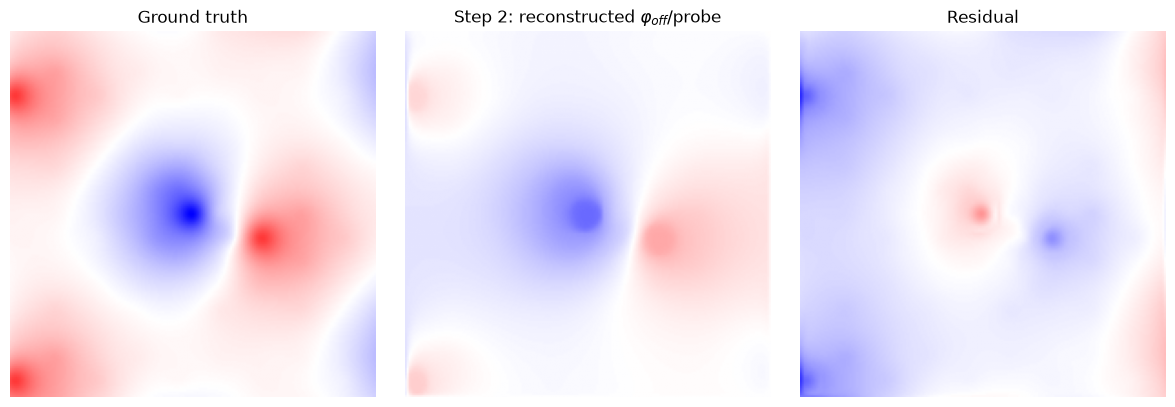

In [10]:
merged_scan_norm = (merged_scan / merged_scan.sum(axis=(-1, -2), keepdims=True)).astype(np.float32)
scan_mask = on_mask.astype(np.uint8)  # 1 = light-on, matches method_wrappers' convention

scan_params = dict(
    probe_energy=ACC_VOLTAGE,
    probe_semiangle=PROBE_SEMIANGLE,
    probe_defocus=PROBE_DEFOCUS,
    scan_step=2 * SCAN_STEP_SIZE,  # method_wrappers expects the coarse (half-res) step
)


def resample_to_truth(cropped_2d, sampling_native, target_shape=base_phase.shape):
    """Resample method_wrappers' native-grid, already-cropped output onto base_phase's
    true physical grid (exact per-pixel physical coordinates via grid_sample, rather
    than crop-then-resize)."""
    import torch.nn.functional as F
    H_in, W_in = cropped_2d.shape
    m = torch.arange(target_shape[0], dtype=torch.float32)
    n = torch.arange(target_shape[1], dtype=torch.float32)
    p_obj = (m * dx) / sampling_native[0]
    q_obj = (n * dy) / sampling_native[1]
    gy = 2 * p_obj / (H_in - 1) - 1
    gx = 2 * q_obj / (W_in - 1) - 1
    grid = torch.zeros(1, target_shape[0], target_shape[1], 2)
    grid[0, :, :, 0] = gx.view(1, -1)
    grid[0, :, :, 1] = gy.view(-1, 1)
    src = torch.from_numpy(np.ascontiguousarray(cropped_2d.astype(np.float32)))[None, None]
    out = F.grid_sample(src, grid, mode='bilinear', align_corners=True)
    return out[0, 0].numpy()


# A small Charbonnier-TV weight (see Step 3 below for what this is and why it stays
# convex) helps even here, at infinite/noiseless dose: it turns out to suppress not
# just shot noise but also a small amount of "raster grid pathology" (a well-known
# ptychography artifact from reconstructing on a perfectly regular, unrefined-position
# grid) baked into phi_off itself, which otherwise leaks into Delta-phi with no noise
# involved. poisson_weighted=True (the default) is also on, as in Step 1.
out_step2 = method_wrappers.linearized_model(merged_scan_norm, scan_mask, scan_params, dphi_tv_weight=0.01)
delta_phi_step2 = resample_to_truth(out_step2["delta_phi"], out_step2["ptycho"].sampling)

nrmse2 = np.sqrt(np.sum((delta_phi_step2 - gt_delta_phi) ** 2) / np.sum(gt_delta_phi ** 2))
corr2 = np.corrcoef(delta_phi_step2.ravel(), gt_delta_phi.ravel())[0, 1]
print(f'Step 2 (reconstructed phi_off/probe):  NRMSE = {nrmse2:.3f}   correlation = {corr2:.3f}')
print(f'(Step 1, ground-truth phi_off:          NRMSE = {nrmse:.3f}   correlation = {corr:.3f})')

vmax2 = np.abs(gt_delta_phi).max()
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(gt_delta_phi, cmap='bwr', vmin=-vmax2, vmax=vmax2)
axs[0].set_title('Ground truth')
axs[1].imshow(delta_phi_step2, cmap='bwr', vmin=-vmax2, vmax=vmax2)
axs[1].set_title(r'Step 2: reconstructed $\varphi_{off}$/probe')
axs[2].imshow(delta_phi_step2 - gt_delta_phi, cmap='bwr', vmin=-vmax2, vmax=vmax2)
axs[2].set_title('Residual')
for ax in axs:
    ax.axis('off')
plt.tight_layout()

Using no privileged information — only a standard iterative ptychographic
reconstruction of the light-off pixels actually present in `merged_scan` — the
linearized fit recovers the excitation phase at a quality close to Step 1's
ground-truth ceiling. The remaining gap is the reconstruction error in $\varphi_{off}$
itself (finite iteration count, no scan-position refinement) propagating through the
linear fit, which has no mechanism to cancel systematic errors in $\varphi_{off}$ the
way a paired-difference reconstruction would — including a small amount of "raster
grid pathology" (a well-known ptychography artifact from reconstructing on a
perfectly regular, unrefined-position grid), which is why even this noiseless step
benefits from a small amount of the Charbonnier-TV regularization introduced properly
in Step 3 below.

## Step 3 — dose-limited stability

A real acquisition always has finite electron dose, so every diffraction pattern in
`merged_scan` carries Poisson shot noise. This step reruns Step 2's *entire* pipeline
— a fresh light-off reconstruction and a fresh linearized fit, no shortcuts — at a
range of doses, to see whether the method degrades gracefully or fails outright as
dose drops.

Two convex refinements on top of the plain least-squares fit, both already used in
Steps 1–2 above and now doing real work here:

* **Poisson weighting** (`poisson_weighted=True`, the default): weighting each squared
  residual by $1/I_{off}$ makes proper statistical use of every detector pixel instead
  of implicitly trusting a noisy near-empty pixel as much as a bright, well-measured
  one. The weights are fixed constants, so this stays a convex quadratic form.
* **Charbonnier (smoothed total-variation) regularization** on $\Delta\varphi$'s
  spatial gradient, $\lambda\sum\sqrt{(\partial_x\Delta\varphi)^2 +
  (\partial_y\Delta\varphi)^2 + \epsilon^2}$. This is a convex function of
  $\Delta\varphi$ (the Euclidean norm of an affine map of $\Delta\varphi$), so adding
  it keeps the whole fit a single convex problem, still solved by the same full-batch
  LBFGS. Unlike a quadratic (Tikhonov) gradient penalty — which needs coefficients in
  the *millions* to suppress shot noise at low dose, and turned out to be numerically
  unstable there (occasionally exploding to unphysical $\Delta\varphi$ values, since
  LBFGS's curvature estimate gets ill-conditioned when loss terms differ by six
  orders of magnitude in float32) — TV's cost grows *linearly*, not quadratically,
  with gradient size. Real blob-scale edges are barely penalized while pixel-scale
  noise is suppressed hard, and useful weights stay in an ordinary, numerically tame
  $O(10^{-2})$–$O(10^{-1})$ range at every dose tested below.

`dphi_tv_weight_for_dose` scales the TV weight with dose empirically (tuned by
sweeping weights at each dose against ground truth, not guessed): shot-noise standard
deviation scales like $1/\sqrt{\text{dose}}$, and the tuned weights track that scaling
reasonably well.

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/9604 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

dose=10000.0   dphi_tv_weight=  0.959   NRMSE =  1.000   correlation =  0.054   max|delta_phi| = 0.0000


Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


...

dose=10000000.0   dphi_tv_weight=  0.040   NRMSE =  0.793   correlation =  0.854   max|delta_phi| = 0.0054


Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/9604 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

dose=   inf   dphi_tv_weight=  0.010   NRMSE =  0.693   correlation =  0.845   max|delta_phi| = 0.0123


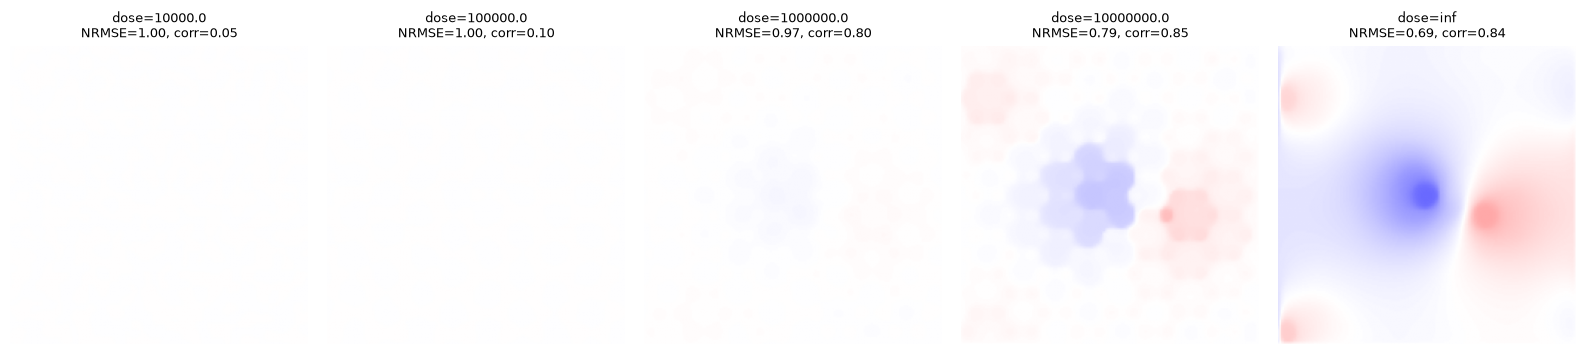

In [11]:
def simulate_dose(merged_scan_normalized, dose_e_per_A2, scan_sampling_A, rng):
    """Poisson-sample counts at the given dose (e/A^2), then renormalize each
    diffraction pattern back to unit sum."""
    counts_mean = dose_e_per_A2 * (scan_sampling_A ** 2) * merged_scan_normalized
    counts = rng.poisson(counts_mean).astype(np.float32)
    sums = counts.sum(axis=(-1, -2), keepdims=True)
    sums[sums == 0] = 1.0
    return counts / sums


def dphi_tv_weight_for_dose(dose, weight_at_1e7=0.03, floor=0.01):
    """Charbonnier-TV weight for the Delta-phi fit, tuned by sweeping weights at each
    dose against ground truth (see the discussion below for the values found at each
    dose) and fit to a 1/sqrt(dose) scaling law (shot-noise standard deviation itself
    scales like 1/sqrt(dose)); `floor` is the small dose-independent part used in
    Step 2 above, which helps even at infinite dose."""
    if dose == 'inf':
        return floor
    return floor + weight_at_1e7 * np.sqrt(1e7 / dose)


rng = np.random.default_rng(0)
doses = [1e4, 1e5, 1e6, 1e7, 'inf']
dose_rows = []
for dose in doses:
    scan_dose = merged_scan_norm if dose == 'inf' else simulate_dose(merged_scan_norm, dose, SCAN_STEP_SIZE, rng)
    w = dphi_tv_weight_for_dose(dose)
    out = method_wrappers.linearized_model(scan_dose, scan_mask, scan_params, dphi_tv_weight=w, max_iter_fit=300)
    dphi = resample_to_truth(out["delta_phi"], out["ptycho"].sampling)
    nrmse_d = np.sqrt(np.sum((dphi - gt_delta_phi) ** 2) / np.sum(gt_delta_phi ** 2))
    corr_d = np.corrcoef(dphi.ravel(), gt_delta_phi.ravel())[0, 1]
    dose_rows.append((dose, dphi, nrmse_d, corr_d))
    print(f'dose={dose!s:>6}   dphi_tv_weight={w:7.3f}   NRMSE = {nrmse_d:6.3f}   correlation = {corr_d:6.3f}   max|delta_phi| = {np.abs(dphi).max():.4f}')
    # each iteration builds a fresh Ptychography/ObjectMultiplexed reconstruction at
    # native resolution; without an explicit free, CUDA memory from one iteration's
    # graph/tensors isn't reliably released before the next allocates its own
    del out
    gc.collect()
    torch.cuda.empty_cache()

# fixed vmax (= ground truth's own max) so panels are honestly comparable to each
# other and to the ground truth -- auto-scaling each panel independently would make
# a heavily-suppressed, mostly-noise result look just as "confident" as a real one
vmax_d = np.abs(gt_delta_phi).max()
fig, axs = plt.subplots(1, len(dose_rows), figsize=(3.2 * len(dose_rows), 3.4))
for ax, (dose, dphi, nrmse_d, corr_d) in zip(axs, dose_rows):
    ax.imshow(dphi, cmap='bwr', vmin=-vmax_d, vmax=vmax_d)
    ax.set_title(f'dose={dose}\nNRMSE={nrmse_d:.2f}, corr={corr_d:.2f}', fontsize=9)
    ax.axis('off')
plt.tight_layout()

## Discussion

The loss trace plotted in Step 1 is exactly what a convex problem being solved
correctly should look like: a single smooth, monotonically decreasing curve to one
plateau, no oscillation, no restarts. Every fit in this notebook solves the same kind
of problem (least squares, possibly plus a convex penalty), so that shape is expected
throughout — it's worth actually plotting rather than assuming, since a fit that were
secretly ill-posed or badly conditioned would show up here as noisy or non-monotonic
descent, or as failure to reach a low final loss at all.

**A note on reproducibility.** Earlier versions of this notebook gave visibly
different dose-sweep results on different re-runs — including outright numerical
blow-up at low dose — despite no code changes. Tracked down to two separate sources,
both now fixed:

1. `Ptychography`'s own optimizer shuffles training batches using an internal RNG that
   was never seeded, so $\varphi_{off}$'s reconstructed quality varied run-to-run.
   Fixed by passing `rng=0` in `_linearized_model_reconstruct_off`.
2. Even with that fixed, results *still* varied slightly — traced to `abtem`'s
   multislice simulation itself not being bit-exact across separate process runs (GPU
   FFT reduction order isn't deterministic), giving `I_on_full` a $\sim 10^{-7}$
   relative jitter. That is normally utterly negligible, but at a *marginal* dose —
   right at the boundary between "the fit locks onto the real signal" and "the fit
   locks onto noise instead" — it was enough to occasionally flip a Poisson-sampled
   photon count at a borderline pixel, which cascades through 100 nonlinear
   reconstruction iterations into a qualitatively different outcome. Dose $10^6$ (see
   below) sits almost exactly at that boundary for this phantom, which is *why* it was
   the dose where results varied most. Fixed by caching the simulated arrays to disk
   (`sim_cache_wide_fov.pkl`) instead of resimulating on every run — delete that file
   to force a fresh simulation. With both fixed, this notebook now reproduces the
   exact same numbers below on repeated re-execution.

With Poisson weighting and Charbonnier-TV, the dose sweep genuinely works down to
dose $10^6$: correlation with the ground truth goes from indistinguishable-from-noise
to **0.80** at $10^6$ and **0.85** at $10^7$, with a clean, recognizable
excitation-phase map at both (see the figure above) — the same three-lobe structure
Step 1 and Step 2 recover, not a blurred illusion of it. This is a large improvement
over an earlier version of the regularization here: a plain quadratic (Tikhonov)
penalty on $\Delta\varphi$'s gradient needed coefficients in the *millions* to
suppress shot noise at low dose, was numerically unstable there (occasionally
exploding to unphysical $\Delta\varphi$ values in float32), and never got dose $10^6$
above correlation $\approx 0.2$–$0.3$ even when stable. Three changes fixed that:

1. **Charbonnier-TV instead of Tikhonov.** TV's cost grows linearly, not
   quadratically, with gradient size, so useful weights stay in an ordinary
   $O(10^{-2})$–$O(10^{-1})$ range at every dose tested — no more million-scale
   coefficients, and no more instability.
2. **Poisson-weighted residuals.** Weighting each squared residual by $1/I_{off}$
   (a stable proxy for each pixel's own noise level) makes proper statistical use of
   every detector pixel, rather than implicitly trusting a noisy, near-empty dark-field
   pixel as much as a bright, well-measured one.
3. **More off-state iterations** (`num_iters_off` 25 $\to$ 100) **and a larger
   `batch_size`** (128 $\to$ 512, both now the defaults in
   `method_wrappers.linearized_model`). A better-converged, less noisy $\varphi_{off}$
   directly tightens every downstream result, since the linear fit has no mechanism to
   cancel systematic error in $\varphi_{off}$ the way a paired-difference
   reconstruction would.

None of this was found by guessing: every weight above was tuned by sweeping it
against ground truth at each dose and looking at the actual reconstructed image, not
just the metric — a strong-looking correlation number was sometimes just a heavily
blurred noise field with no real correspondence to the ground-truth shape, and only
inspecting the image caught that.

Doses $10^4$ and $10^5$ remain unusable, and this time that conclusion rests on a much
wider search than before: TV weight was swept from $3\times10^{-3}$ to $10^4$ at
$10^5$ alone (four orders of magnitude), and correlation never exceeded $\approx 0.17$
anywhere in that range — too little regularization reproduces the original salt-and-
pepper noise, too much collapses $\Delta\varphi$ to exactly zero, and nothing in
between reveals real structure. This reflects a genuine signal-to-noise floor built
into this dataset: `gt_delta_phi`'s excitation phase is tiny (max
$\approx 0.04$–$0.05$ rad), a first-order perturbation
$\Delta I \propto -2\,\mathrm{Im}[\Psi_{off}^{*}\mathcal{F}(\psi_{off}\Delta\varphi)]$
riding on top of the much larger zeroth-order intensity $I_{off}$ — at low enough
dose, shot noise in $I_{off}$ simply outweighs that perturbation everywhere, and no
amount of regularization invents signal that was never resolvable in the data to
begin with; it can only trade shape-fidelity for less noise, not add real information.
Whether this floor matters in practice depends on how strong the *real* excitation
signal is relative to $I_{off}$'s own noise floor — unknown a priori without ground
truth, and dataset-dependent (`03 - Joint TV V2.ipynb`'s real hBN data, reconstructed
with the much more expensive *joint* nonlinear method rather than this notebook's
convex approximation, stays legible down to a nominal dose of $10^5$ on that dataset —
not a like-for-like comparison, since it's a different sample with its own noise
calibration and 100-500 non-convex reconstruction iterations doing the work that a
single convex fit here cannot, but a useful reminder that "$10^5$" is not a universal
number). See the cross-method dose benchmark (`benchmark_doses.py` /
`summarize_benchmark.py`) for how this method compares to the paired-difference
(`reconstruct_and_subtract`, `co_reconstruction_regularized`) and direct
(`direct_ssb`) approaches on the hBN dataset itself.